In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
df = pd.read_csv("Iris.csv")
df.drop(["Id"],axis=1 ,inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


now checking null values and what datatypes are here

In [4]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.dtypes

SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [8]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [9]:
df["Species"].unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [10]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

doing some operations

In [11]:
x= df.drop("Species",axis=1)
y= df["Species"]

co realtion test

In [12]:
from scipy.stats import f_oneway

features = ["SepalLengthCm", "SepalWidthCm",
            "PetalLengthCm", "PetalWidthCm"]

for feature in features:

    setosa = df[df["Species"] == "Iris-setosa"][feature]
    versicolor = df[df["Species"] == "Iris-versicolor"][feature]
    virginica = df[df["Species"] == "Iris-virginica"][feature]

    f_stat, p_value = f_oneway(setosa, versicolor, virginica)

    print("\n", feature)
    print("F-statistic:", f_stat)
    print("P-value:", p_value)
    if p_value < 0.05:
        print("Significant difference → Feature is useful")
    else:
        print("No significant difference → Feature may not be useful")


 SepalLengthCm
F-statistic: 119.26450218450468
P-value: 1.6696691907693826e-31
Significant difference → Feature is useful

 SepalWidthCm
F-statistic: 47.36446140299382
P-value: 1.3279165184572094e-16
Significant difference → Feature is useful

 PetalLengthCm
F-statistic: 1179.0343277002219
P-value: 3.0519758018273866e-91
Significant difference → Feature is useful

 PetalWidthCm
F-statistic: 959.3244057257591
P-value: 4.376956957489586e-85
Significant difference → Feature is useful


In [13]:
corr= x.corr()
for element in x.columns:
    print(f"-------------{element}--------- \n", corr[element].sort_values(ascending=False),"\n")

-------------SepalLengthCm--------- 
 SepalLengthCm    1.000000
PetalLengthCm    0.871754
PetalWidthCm     0.817954
SepalWidthCm    -0.109369
Name: SepalLengthCm, dtype: float64 

-------------SepalWidthCm--------- 
 SepalWidthCm     1.000000
SepalLengthCm   -0.109369
PetalWidthCm    -0.356544
PetalLengthCm   -0.420516
Name: SepalWidthCm, dtype: float64 

-------------PetalLengthCm--------- 
 PetalLengthCm    1.000000
PetalWidthCm     0.962757
SepalLengthCm    0.871754
SepalWidthCm    -0.420516
Name: PetalLengthCm, dtype: float64 

-------------PetalWidthCm--------- 
 PetalWidthCm     1.000000
PetalLengthCm    0.962757
SepalLengthCm    0.817954
SepalWidthCm    -0.356544
Name: PetalWidthCm, dtype: float64 



DATA VISUALISATION

<Axes: xlabel='SepalLengthCm', ylabel='Count'>

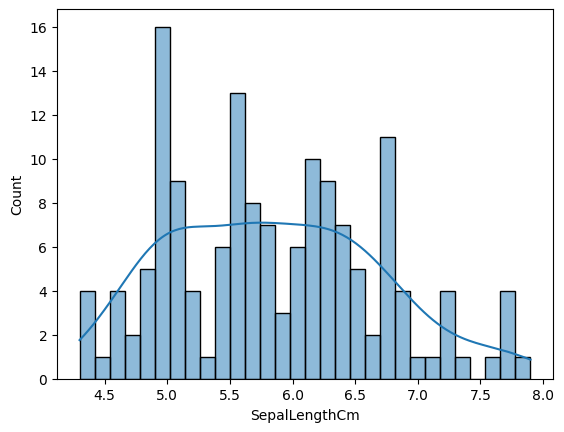

In [14]:
sns.histplot(x=df["SepalLengthCm"], bins=30,kde=True)


<Axes: >

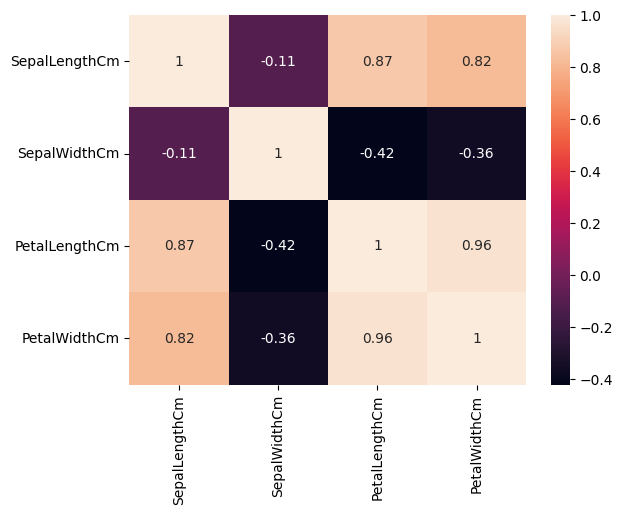

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [16]:
x.columns


Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='str')

TRAIN TEST SPLIT

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.33,random_state=40)


standarization

In [18]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train_standarized= scaler.fit_transform(x_train)



TRAINING MODEL

In [19]:
cross_dict= {}

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score

models= {"tree":DecisionTreeClassifier(),"SVM":SVC(),"logistic regression":LogisticRegression(),"naive byes":GaussianNB(),"forest":RandomForestClassifier()}
for name,model in models.items():
    model.fit(x_train,y_train)
    prediction=model.predict(x_test)
    prediction_train= model.predict(x_train)
    report = classification_report(y_test,prediction)
    accuracy = accuracy_score(y_test,prediction)
    
    print(f"------{name}----","\n",report,"\n")
    print("accuracy of the modeel ",accuracy)
    train_accuracy = accuracy_score(y_train,prediction_train)
    print("training accuracy ",train_accuracy)
    print("___________")
    scores = cross_val_score(estimator=model,X=x_train,y= y_train,cv= 5, scoring="accuracy")
    print(f"{scores} \n {scores.mean()}")
    

    

------tree---- 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        18
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        17

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50
 

accuracy of the modeel  1.0
training accuracy  1.0
___________
[0.95 0.85 0.85 0.95 0.95] 
 0.9099999999999999
------SVM---- 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        18
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.94      0.97        17

       accuracy                           0.98        50
      macro avg       0.98      0.98      0.98        50
   weighted avg       0.98      0.98      0.98        50
 

accuracy of the modeel  0.98
training accuracy  

In [21]:
x.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='str')

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
final_model= SVC()
final_model.fit(x_train,y_train)
final_prediction= final_model.predict(x_test)
accuracy= accuracy_score(y_test,final_prediction)
report = classification_report(y_test,final_prediction)
print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        18
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.94      0.97        17

       accuracy                           0.98        50
      macro avg       0.98      0.98      0.98        50
   weighted avg       0.98      0.98      0.98        50



In [26]:
sepal_length= 5.2
sepal_width= 2.7
petal_length= 3.9
petal_wdith= 1.4
data= [[sepal_length,sepal_width,petal_length,petal_wdith]]
sample_prediction= final_model.predict(data)
print(sample_prediction)

['Iris-versicolor']


c:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [24]:
df["Species"].unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str